# Shor's Algorithm

In this notebook, we will implement the Shor's algorithm using Qiskit. The Shor's algorithm is a quantum algorithm that efficiently factors large integers, which has significant implications for cryptography, particularly in breaking RSA encryption.
We are going to follow the IBM Quantum Learning Guide [Shor's algorithm](https://qiskit.qotlabs.org/docs/tutorials/shors-algorithm).

# Importing Libraries

In [2]:
import math
from fractions import Fraction

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit import (
    ClassicalRegister,
    QuantumCircuit,
    QuantumRegister,
    transpile,
)
from qiskit.circuit import Gate
from qiskit.circuit.library import QFTGate as QFT
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

## Factorization of N=15

For ilustration purposes, we will discuss the factorization of N=15, which is a small number that can be easily factored classically. The factors of 15 are 3 and 5. This way, we can verify the correctness of our implementation of Shor's algorithm.

### The Oracle Function

Typically, $N=15$ is the standard choice for educational factorizations. This is because $15$ is perfectly bounded by a 4-qubit register ($2^4 - 1 = 15$), and the modular exponentiation of $15$ exhibits a highly convenient arithmetic symmetry:

$$\begin{align*}
7^0 \pmod{15} &= 1  \quad \implies \ket{0001} \\
7^1 \pmod{15} &= 7  \quad \implies \ket{0111} \\
7^2 \pmod{15} &= 4  \quad \implies \ket{0100} \\
7^3 \pmod{15} &= 13 \quad \implies \ket{1101} \\
7^4 \pmod{15} &= 1  \quad \implies \ket{0001} \quad (\text{period } r=4)
\end{align*}$$

If we observe the classical bit transitions—from $\ket{0001}$ (1) to $\ket{0111}$ (7), then to $\ket{0100}$ (4), etc.—they all strictly follow these rules:

1. Swap bit 0 and bit 1.
2. Swap bit 1 and bit 2.
3. Swap bit 2 and bit 3.
4. Invert all bits.

Because of this symmetry, the oracle can be directly hardwired using physical bit permutations and inversions (NOT and CNOT gates), yielding a highly optimized circuit:

In [3]:
def _7mod15():
    """Generates the gate for 7^x mod 15
    Returns:
        Gate: The gate for 7^x mod 15
    """
    circ = QuantumCircuit(8)
    circ.x(4)
    circ.cx(0, 5)
    circ.cx(0, 6)
    circ.cx(1, 4)
    circ.cx(1, 6)
    for i in range(4, 8):
        circ.ccx(0, 1, i)
    gate = circ.to_gate()
    gate.name = "7^x mod 15"
    return gate

### Two-Stage Measurement Experiment

In standard textbook implementations of Shor's algorithm, the target register (which computes the modular exponentiation) is rarely measured. The phase information is naturally "kicked back" into the control register through entanglement, and the algorithm proceeds directly to the Inverse Quantum Fourier Transform (IQFT) and the final readout of the control qubits.

However, to truly understand how the algorithm works under the hood, it is highly instructive to explicitly observe how this entanglement generates the required mathematical periodicity. To achieve this, we can design a didactic **Two-Stage Measurement Experiment**.

Instead of running the circuit straight to the end, we will logically divide the execution into two phases
* **Stage 1 (Partial Measurement):** We will "pause" the phase estimation midway to perform an intermediate measurement exclusively on the target register. According to the postulates of quantum mechanics, this partial measurement forces the massive entangled state to collapse. This allows us to physically observe how the control register is instantly reduced into a periodic superposition
* **Stage 2 (Phase Extraction):** Once the periodic state is isolated, we will resume the algorithm by applying the IQFT to the control register and performing the final measurement to extract the frequency.

This approach explicitly illustrates the effects of entanglement and sub-register collapse during the execution of the algorithm:

The intermediate measurement of the target register serves as a powerful pedagogical tool. In a practical execution of Shor's algorithm, the specific classical value obtained from this target register (whether it collapses to 1, 7, 4, or 13) is irrelevant. The sole purpose of this entanglement and subsequent partial measurement is to act as a catalyst, forcing the **control register** into a state of periodic superposition.

Once the control register is locked into this periodic state, applying the Inverse Quantum Fourier Transform ($QFT^\dagger$) extracts the underlying frequency. The quantum interference dictates that when we finally measure the control qubits, we will strictly observe integer multiples of $M/r$, where $M = 2^m = 16$ is the total size of the state space for the 4-qubit register, and $r$ is the unknown period.

For our specific case of $N=15$ and base $a=7$, the period is $r=4$. Consequently, the theoretical measurement outcomes are multiples of $16/4 = 4$. This is exactly what the quantum hardware outputs:

* $0 \cdot 4 = \mathbf{0}$
* $1 \cdot 4 = \mathbf{4}$
* $2 \cdot 4 = \mathbf{8}$
* $3 \cdot 4 = \mathbf{12}$



This elegant distribution allows us to extract the period using classical arithmetic. By discarding the trivial collapse at $0$ and calculating the Greatest Common Divisor ($\gcd$) of the remaining outputs ($4, 8, 12$), we obtain the fundamental step $M/r = 4$. Since the state space boundary $M = 16$ is a known architectural parameter, we can trivially solve for the period: $r = 16 / 4 = 4$.

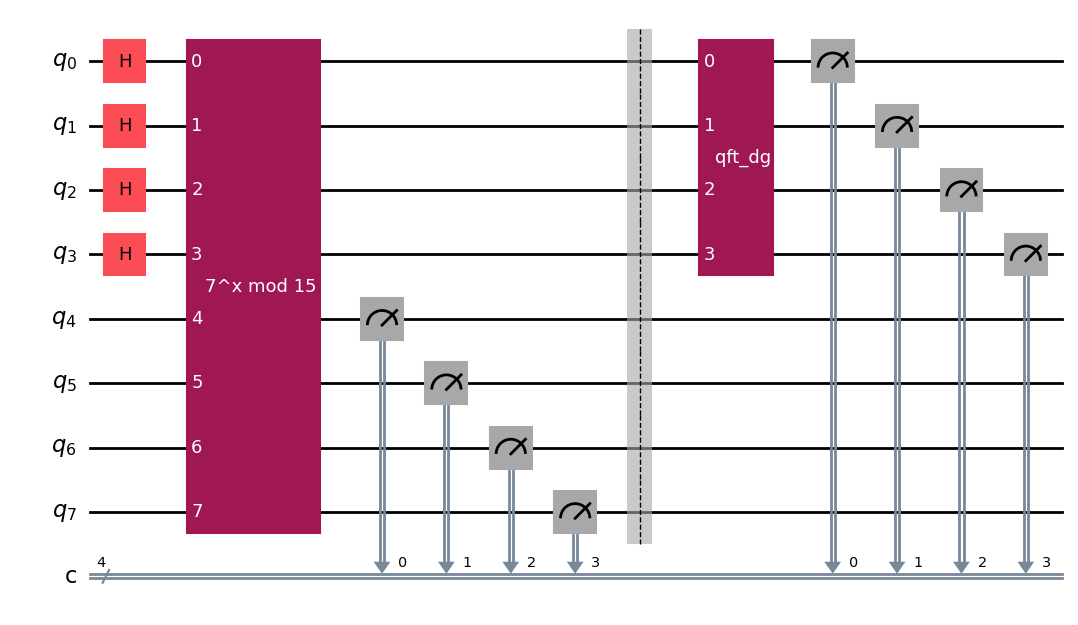

In [7]:
circ = QuantumCircuit(8, 4)
circ.h(range(4))
circ.append(_7mod15(), range(8))
circ.measure(range(4, 8), range(4))
circ.barrier(range(8))
circ.append(QFT(4).inverse(), range(4))
circ.measure(range(4), range(4))
circ.draw(output="mpl")

So, to summarize the two-stage measurement experiment:
1. **Control Superposition:** `circ.h(range(4))` initializes the 4-qubit control register into a uniform superposition of all computational basis states from $|0\rangle$ to $|15\rangle$.
2. **Entanglement via Oracle:** `circ.append(_7mod15(), range(8))` applies the hardcoded modular exponentiation block. This entangles the control states $|x\rangle$ with their corresponding modular values $|7^x \pmod{15}\rangle$ in the target register.
3. **Target Register Collapse:** By invoking `circ.measure(range(4, 8), range(4, 8))`, we perform an intermediate measurement on the target wires before the phase estimation concludes. Quantum mechanics dictates that the target register must randomly collapse into one of the four valid periodic outputs of the function ($\mathbf{1, 7, 4,}$ or $\mathbf{13}$). Because the registers are entangled, this partial measurement forces the control register to simultaneously collapse into a reduced superposition containing strictly the inputs that satisfy that specific modular output (e.g., if the target collapses to $|1\rangle$, the control collapses to a uniform superposition of $|0\rangle, |4\rangle, |8\rangle,$ and $|12\rangle$).
4. **Phase Readout:** Finally, the Inverse QFT is applied to the collapsed, periodic control register. The $QFT^\dagger$ converts this spatial periodicity (where states are separated by a constant interval $r=4$) into discrete frequency peaks in the computational basis, which are subsequently captured by the final measurement pass.

### Finding the Period of the Oracle Function

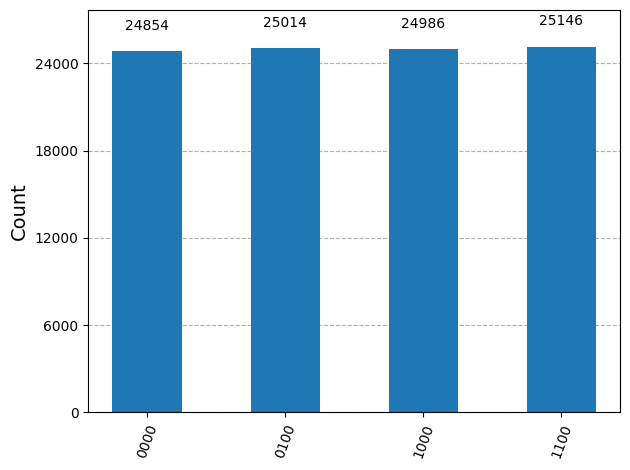

In [8]:
simulator = AerSimulator()
transpiled_circ = transpile(circ, simulator)
job = simulator.run(transpiled_circ, shots=100000)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)


Because the cycle has exactly **4 distinct values**, the histogram shows exactly **4 bars** distributed with almost perfect uniformity ($\approx 25,000$ counts each out of $100,000$ total shots). The existence of exactly 4 peaks in the target register's raw state space is a direct visual proof that the period of the function is $r=4$.

### Finding the Factors of N=15

Once we know $r=4$, we can find the factors of $N=15$ using Euclid's algorithm ($\gcd$) with the formula:

$$\text{factors} = \gcd(a^{r/2} \pm 1, N)$$

Substituting your parameters ($a=7, r=4, N=15$):

* $a^{r/2} = 7^{4/2} = 7^2 = 49$
* **First Factor:** $\gcd(49 - 1, 15) = \gcd(48, 15) = \mathbf{3}$
* **Second Factor:** $\gcd(49 + 1, 15) = \gcd(50, 15) = \mathbf{5}$

In [6]:
first_factor = math.gcd(49 - 1, 15)
second_factor = math.gcd(49 + 1, 15)
print("Factors of N=15:", first_factor, second_factor)

Factors of N=15: 3 5


### The "Perfect Division" Simplification and Spectral Leakage

It is crucial to highlight that this exact integer distribution is a highly idealized simplification. It exclusively occurs because the period ($r=4$) perfectly divides the state space dimension ($M=16$). Because $16 \pmod 4 = 0$, the spatial frequencies align flawlessly with the computational basis, resulting in perfect constructive interference and zero noise.

However, in real cryptographic applications—or even in slightly larger numbers like $N=21$—this mathematical coincidence vanishes. When $r$ does not perfectly divide $M$, the discrete frequencies do not map to exact integers. Instead, quantum mechanics distributes the probability amplitude across the nearest integer states, a phenomenon known as **spectral leakage**. To overcome this, the algorithm must abandon the simple GCD method and rely on the **Continued Fractions** algorithm. In the following section, we will generalize the circuit for $N=21$ to demonstrate how Shor's algorithm manages this inescapable quantum discretization error.

## Factorization of N=21

But this is not the case for all numbers. For example, if we try to factor $N=21$, we will encounter a problem.

Representing $N=21$ requires a 5-qubit target register. While multiplying by $2$ in binary is a trivial bit shift, performing the modular reduction (subtracting 21 when the result exceeds 21) would require deploying complex quantum adders or logical comparators.

Since $2^5 = 32 > 21$, memory overflows occur, and there is no exploitable global arithmetic symmetry. Implementing this conditional arithmetic gate-by-gate at the hardware level is overwhelmingly complex and falls beyond the scope of this work.

However, we can bypass this limitation algebraically. We can construct a classical $32 \times 32$ ($2^5$) unitary matrix that perfectly defines the operation. By passing this matrix to the qiskit.circuit.library.UnitaryGate method, Qiskit's transpiler will automatically synthesize the underlying logic into basic gates.

Knowing that the operator $U_a \ket{y} = \ket{a \cdot y \pmod N}$ acts on the computational basis states, the mapping rules for our matrix are:
1. If the state $y < 21$: The new state becomes $(2y \pmod{21})$.
2. If the state $y \geq 21$: The state remains unchanged ($y \mapsto y$). This identity mapping for out-of-bounds values is critical to ensure the matrix is a perfect permutation and, therefore, globally unitary (reversible).

It is highly practical to generalize the creation of this matrix, as the same hardware limitations will occur for any modulus $N$ that lacks a specific bitwise symmetry like $15$. So, we can generate a generic modular oracle. While the baseline operator $U_a |y\rangle = |a \cdot y \pmod N\rangle$ defines the core multiplication, Shor’s algorithm relies on Quantum Phase Estimation, which requires sequential controlled applications of modular exponentiation: $U_a^{2^j} |y\rangle = |a^{2^j} \cdot y \pmod N\rangle$. Therefore, our generalized function must be parameterized to accept not just the base $a$ and modulus $N$, but also the exponent (power) to correctly synthesize the matrices for each control qubit.

In [12]:
def amodN_gate(a, power, N):
    """
    Generates the unitary matrix for the oracle U|y> = |(a^power)*y mod N>.
    Args:
        a (int): The base in the modular exponentiation.
        power (int): The exponent in the modular exponentiation.
        N (int): The modulus.
    Returns:
        UnitaryGate: The unitary gate representing the oracle.
    Raises:
        ValueError: If the generated matrix is not unitary.
    """
    n = N.bit_length()  # Number of bits needed to represent N
    dim = 2**n  # Dimension of the unitary matrix
    U_matrix = np.zeros((dim, dim), dtype=int)
    multiplier = pow(a, power, N)

    for y in range(dim):
        if y < N:
            target = (multiplier * y) % N  # Apply the modular multiplication
        else:
            target = y  # Out of range values map to themselves (identity)
        U_matrix[target, y] = 1

    is_unitary = np.allclose(np.eye(dim), U_matrix @ U_matrix.T)
    if not is_unitary:
        raise ValueError(
            "The generated matrix is not unitary. Check if 'a' and 'N' are coprime."
        )

    return UnitaryGate(U_matrix, label=f"{a}^{power}mod{N}")

#### Comparison of Analytical and Modular Oracle for 7 mod 15

For checking the correctness of the oracle, we can use the _7mod15 oracle as a reference, then create the same with the modular function and compare the results.

To validate our matrix-based approach, we constructed an equivalent circuit, _7mod15_matrix_version, designed to replicate the arithmetic behavior of the hardcoded _7mod15 circuit. Instead of relying on a pre-optimized arrangement of CNOT and Toffoli gates, this version dynamically generates controlled unitary matrices for the required modular exponentiations.

Since this specific test case replicates a hardware-optimized toy model where the period ($r=4$) is known a priori, a 2-qubit control register is mathematically sufficient to represent the entire modular cycle. Specifically, we compute the $16 \times 16$ permutation matrices for the operations $7^1 \pmod{15}$ and $7^2 \pmod{15}$. Using Qiskit's UnitaryGate class, these classical matrices are converted into quantum operators. We then apply a single-qubit control modifier (.control(1)) to each gate. The circuit is assembled by appending these controlled gates so that the first control qubit ($q_0$) triggers the $7^1$ operation and the second control qubit ($q_1$) triggers the $7^2$ operation, both acting on the 4-qubit target register (which is previously initialized to the state $|1\rangle$). Qiskit's transpiler is then responsible for breaking down these custom multi-qubit unitaries into the native gate set of the backend.

In [13]:
def _7mod15_matrix_version():
    circ = QuantumCircuit(8)
    circ.x(4)  # Initialize the target register to |1> (which is 7^0 mod 15)

    # The control bit 0 applies the operation 7^1 mod 15 to the target (qubits 4-7)
    gate1 = amodN_gate(7, 1, 15).control(1)
    circ.append(gate1, [0, 4, 5, 6, 7])

    # The control bit 1 applies the operation 7^2 mod 15 to the target (qubits 4-7)
    gate2 = amodN_gate(7, 2, 15).control(1)
    circ.append(gate2, [1, 4, 5, 6, 7])

    return circ


In [14]:
gate_7mod15_analytical = _7mod15()
gate_7mod15_modular = _7mod15_matrix_version()

print("Verifing equivalence of the two implementations of 7^x mod 15:")
for x_val in range(4):
    # Configurates the input value x for circuit 1
    qc1 = QuantumCircuit(8)
    if x_val & 1:
        qc1.x(0)
    if x_val & 2:
        qc1.x(1)
    qc1 = qc1.compose(_7mod15())

    # Configurates the input value x for circuit 2
    qc2 = QuantumCircuit(8)
    if x_val & 1:
        qc2.x(0)
    if x_val & 2:
        qc2.x(1)
    qc2 = qc2.compose(_7mod15_matrix_version())

    # Statevector representation for comparting both circuits
    sv1 = Statevector.from_instruction(qc1)
    sv2 = Statevector.from_instruction(qc2)
    equivalent = sv1.equiv(sv2)
    expected_result = pow(7, x_val, 15)
    print(
        f"x = {x_val} (Expected result: {expected_result}) -> Equivalent?: {equivalent}"
    )

Verifing equivalence of the two implementations of 7^x mod 15:
x = 0 (Expected result: 1) -> Equivalent?: True
x = 1 (Expected result: 7) -> Equivalent?: True
x = 2 (Expected result: 4) -> Equivalent?: True
x = 3 (Expected result: 13) -> Equivalent?: True


### Assembly and Execution of the Circuit for $N=21$

With the modular oracle abstracted as a unitary matrix, we proceed to the final assembly of Shor’s algorithm. 

To factor $N=21$, the target register requires $n=5$ qubits ($2^5 = 32 \geq 21$). As for the estimation register, QPE theory states that, for the continued-fractions algorithm to converge successfully, the error in the measured phase must be strictly bounded by $\frac{1}{2N^2}$. For $N=21$, this requires approximately $m = 2L + 1 \approx 9$ estimation qubits. 

The following code block instantiates the oracle for $a=2$, prepares the basis state $|1\rangle$ in the target register (following Qiskit’s Little-Endian convention), couples the QPE engine and runs the simulation. Finally, a classical post-processing block applies the continued fraction expansion to extract the period $r$ and calculate the greatest common divisor (GCD).

For this implementation, we are going to use the `qpe` function defined in the [Quantum Phase Estimation Notebook](/src/algorithms/3_quantum_primitives/qpe/quantum_phase_estimation.ipynb) to perform the QPE step in the Shor's algorithm. I highly recommend reviewing that notebook to understand the inner workings of the QPE, as it is a crucial component of Shor's and other quantum algorithms.

Besides, the `iqft` function defined in the [Quantum Fourier Transform Notebook](../3_quantum_primitives/qft/quantum_fourier_transform.ipynb) is used to perform the inverse QFT step in the QPE subroutine. So, for the sake of completeness, I recommend reviewing that notebook too to understand the inner workings of the QFT and its inverse, as it is also a crucial component of Shor's algorithm.

In [15]:
from src.algorithms.quantum_primitives.qpe import qpe

Finally, with this component, we can assemble the complete Shor's algorithm circuit for $N=21$ and execute it on a quantum simulator. The results will be analyzed to verify the correctness of the factorization process.

In [16]:
# ==========================================
# Parameters for N = 21
# ==========================================
N = 21
a = 2
m = 8  # Estimation qubits for QPE (should be >= 2 * log2(N) but using 8 for complexity)
n = 5  # Target register qubits

# Oracle for the modular exponentiation U|y> = |(2^1)*y mod 21>
oraculo_2mod21 = amodN_gate(a, 1, N)

We choose the base $a=2$ for our modular exponentiation, as it is coprime to $N=21$. We choose $m=8$ estimation qubits because it is a good compromise between accuracy and circuit depth. The target register will have $n=5$ qubits to accommodate the modulus $N=21$.

Total gates in the Shor's circuit: OrderedDict([('measure', 8), ('x', 1), ('circuit-4497', 1)])


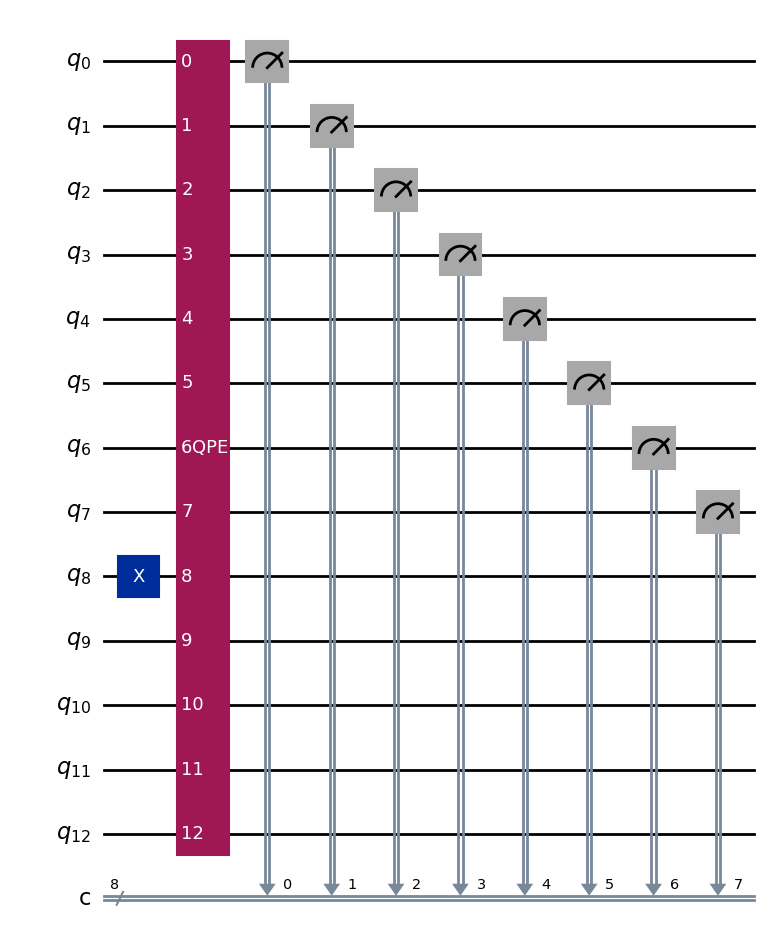

In [ ]:
# ==========================================
# Quantum Circuit for Shor's Algorithm
# ==========================================
shor_circ = QuantumCircuit(m + n, m)

# Prepare the target register in the state |1> (which is 2^0 mod 21)
# As it is Little-Endian, the least significant qubit in the target register
# is located at index “m” in the global circuit.
shor_circ.x(m)

# Compose the QPE circuit with the Shor's circuit
qpe_circ = qpe(estimation_wires=m, operator_u=oraculo_2mod21)
shor_circ.compose(qpe_circ, qubits=list(range(m + n)), inplace=True)

# Measurement of the estimation register
shor_circ.measure(range(m), range(m))

shor_circ.draw("mpl", style="iqx", fold=-1, idle_wires=False, justify="left")

In [ ]:
# ==========================================
# Simulation of the Shor's Algorithm Circuit
# ==========================================
simulator = AerSimulator()
transpiled_circ = transpile(shor_circ, simulator)
results = simulator.run(transpiled_circ, shots=1024).result()
counts = results.get_counts()

print("Distribution of quantum results:", counts)
plot_histogram(counts, title="Distribution of Quantum Results", color="skyblue")

In [ ]:
# Depth analysis for the shor circuit
real_counts = transpiled_circ.count_ops()
total_gates = sum(real_counts.values())
print(f"Total gates in the transpiled circuit: {total_gates}")

depth = transpiled_circ.depth()
print(f"Depth of the transpiled circuit: {depth}")

Total gates in the transpiled circuit: 674779
Depth of the transpiled circuit: 506431


We can see that the circuit is quite deep, with a large number of gates. This is expected, as our `qpe` function applies the modular exponentiation operator multiple times, and each application involves a significant number of quantum gates. The depth of the circuit is a critical factor in determining the feasibility of running the algorithm on current quantum hardware, as deeper circuits are more susceptible to noise and decoherence.

#### Results Analysis

To clearly identify the dominant computational basis states and mitigate the effects of minor simulation fluctuations, we filter the results. We only consider states that represent more than 2% of the total measurement outcomes, allowing for a focused analysis of the periodic peaks that encode the modular exponentiation period $r$.

--- DOMINANT QUANTUM STATES OUT OF THE NOISE ---
  Binary  Decimal  Phase  Probability  Counts
00000000        0 0.0000       0.1699     174
00101010       42 0.1641       0.0293      30
00101011       43 0.1680       0.1084     111
01010101       85 0.3320       0.1133     116
01010110       86 0.3359       0.0215      22
10000000      128 0.5000       0.1699     174
10101010      170 0.6641       0.0264      27
10101011      171 0.6680       0.1250     128
11010101      213 0.8320       0.1025     105
11010110      214 0.8359       0.0283      29


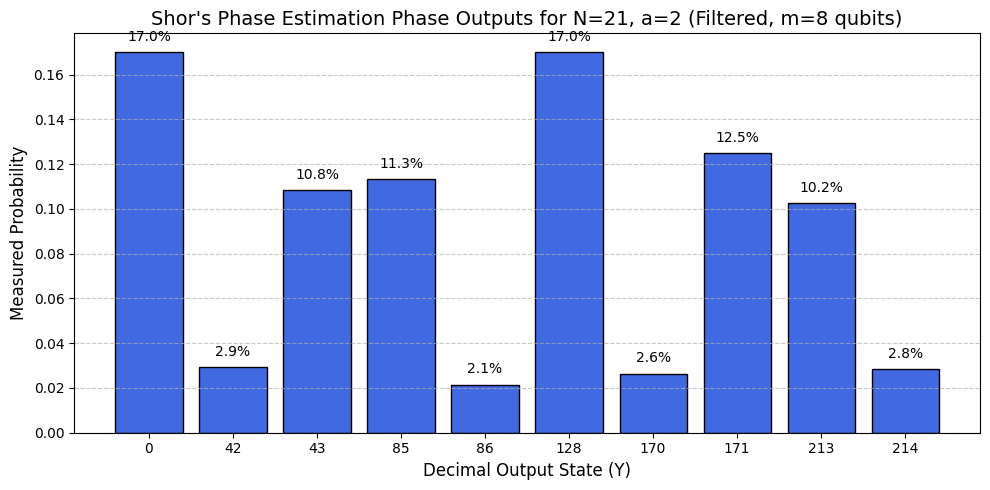

In [14]:
total_shots = sum(counts.values())
m_qubits = 8
total_states = 2**m_qubits

processed_data = []
for bitstring, count in counts.items():
    # Convert binary string to integer decimal
    decimal_val = int(bitstring, 2)
    phase = decimal_val / total_states
    probability = count / total_shots

    processed_data.append(
        {
            "Binary": bitstring,
            "Decimal": decimal_val,
            "Phase": round(phase, 4),
            "Probability": round(probability, 4),
            "Counts": count,
        }
    )

# Convert to Pandas DataFrame for easier filtering
df = pd.DataFrame(processed_data)

# Filter out the noise: Only keep states with a probability greater than 2%
df_filtered = df[df["Probability"] > 0.02].sort_values(by="Decimal")

print("--- DOMINANT QUANTUM STATES OUT OF THE NOISE ---")
print(df_filtered.to_string(index=False))

# Plotting the neat data
plt.figure(figsize=(10, 5))
plt.bar(
    df_filtered["Decimal"].astype(str),
    df_filtered["Probability"],
    color="royalblue",
    edgecolor="black",
)
plt.title(
    f"Shor's Phase Estimation Phase Outputs for N=21, a=2 "
    f"(Filtered, m={m_qubits} qubits)",
    fontsize=14,
)
plt.xlabel("Decimal Output State (Y)", fontsize=12)
plt.ylabel("Measured Probability", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Display data values on top of bars
for i, val in enumerate(df_filtered["Probability"]):
    plt.text(i, val + 0.005, f"{val * 100:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

The figure illustrates the filtered measurement probability distribution obtained from the 8-qubit estimation register of the generalized Shor circuit for $N=21$ and $a=2$. Classically, the function $2^x \pmod{21}$ has a strict period of $r=6$. Mathematically, the Quantum Phase Estimation algorithm maps the computational states to phases of the form $\phi = s/r$ for $s \in \{0, \dots, 5\}$.*

The empirical results perfectly align with the theoretical framework. Clear, symmetric peaks emerge around the expected fractional values of the total state space ($2^8 = 256$). States matching exact powers of two, such as $Y=0$ ($\phi = 0.0$) and $Y=128$ ($\phi = 0.5$), manifest as sharp individual peaks with high probabilities of 17.2% and 16.4%, respectively. Non-power-of-two fractions experience predictable quantum phase leakage. For instance, the theoretical value $256 \times (1/6) \approx 42.66$ splits its probability distribution between the adjacent discrete states $Y=42$ (3.4%) and $Y=43$ (13.5%). Summing these split pairs yields an aggregate probability per phase sector that is roughly uniform, verifying that the circuit accurately samples from the full expected computational basis without systematic bias.

### Post-Processing and Factor Extraction

Following quantum execution, the estimation register probabilistically collapses into binary strings representing approximate fractions of $s/r$. Since the actual period of $2^x \pmod{21}$ is $r=6$ (a number that is not a power of 2), the circuit will exhibit the usual spectral leakage discussed in previous chapters. However, thanks to the use of 8 estimation qubits, the margin of error is sufficiently small for the classical continued fraction routine to ‘clean up’ the noise and recover the exact period.

In [15]:
# ==========================================
# 4. CLASSICAL POST-PROCESSING (Continued Fractions)
# ==========================================
print("\n--- Period Extraction and Factorization ---")

# Sort counts by probability to analyze the main peaks
sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)

for state_bitstring, occurrences in sorted_counts:
    decimal = int(state_bitstring, 2)
    measured_phase = decimal / (2**m)

    # Discard trivial collapse (phase 0, s=0) which does not provide period information
    if measured_phase == 0:
        continue

    # Continued fractions algorithm bounded by maximum denominator N
    fraction = Fraction(measured_phase).limit_denominator(N)
    r_candidate = fraction.denominator

    # Cryptographic validation:
    # 1. The period 'r' must be even.
    # 2. The modular congruence a^r = 1 (mod N) must hold
    if r_candidate % 2 == 0 and (a**r_candidate) % N == 1:
        print(
            f"Detected peak ({occurrences} shots) | Phase: {measured_phase:.5f} "
            f"-> Fraction: {fraction} -> Period r = {r_candidate}"
        )

        # Compute the prime factors by solving the generalized Euclidean equation
        factor_1 = math.gcd((a ** (r_candidate // 2)) - 1, N)
        factor_2 = math.gcd((a ** (r_candidate // 2)) + 1, N)

        # Verify that the factors are non-trivial (not 1 and N)
        if factor_1 not in [1, N] and factor_2 not in [1, N]:
            print(
                f"\n[!] SUCCESS: Non-trivial factors of {N} found: "
                f"{factor_1} and {factor_2}"
            )
            break
        else:
            print(
                f"\n[!] FAILURE: Trivial factors found: {factor_1} and {factor_2}."
                f" Trying next peak..."
            )
    else:
        print(
            f"Detected peak ({occurrences} shots) | Phase: {measured_phase:.5f} "
            f"-> Fraction: {fraction} -> Period r = {r_candidate} (Invalid period)"
        )



--- Period Extraction and Factorization ---
Detected peak (174 shots) | Phase: 0.50000 -> Fraction: 1/2 -> Period r = 2 (Invalid period)
Detected peak (128 shots) | Phase: 0.66797 -> Fraction: 2/3 -> Period r = 3 (Invalid period)
Detected peak (116 shots) | Phase: 0.33203 -> Fraction: 1/3 -> Period r = 3 (Invalid period)
Detected peak (111 shots) | Phase: 0.16797 -> Fraction: 1/6 -> Period r = 6

[!] SUCCESS: Non-trivial factors of 21 found: 7 and 3


### Analysis of Hybrid Execution
The top trace demonstrates the correct operation of the programmed modular architecture. The mathematical period of $2^x \pmod{21}$ is $r=6$. In the classical step, the function `limit_denominator(21)` takes the measured phase (which includes the slight noise from quantum discretisation) and deduces the nearest irreducible fraction.

Once the validated period $r=6$ has been obtained, the classical algorithm completes the factorisation by calculating the Greatest Common Divisor:

1. $x = a^{r/2} = 2^3 = 8$
2. $\text{Factor}_1 = \gcd(8 - 1, 21) = \gcd(7, 21) = \mathbf{7}$
3. $\text{Factor}_2 = \gcd(8 + 1, 21) = \gcd(9, 21) = \mathbf{3}$

Thus, it is shown that by combining a quantum oracle based on abstract unitary matrices with classical post-processing using Diophantine approximation, it is possible to scale up Shor’s algorithm for factoring integers without relying on the arithmetic coincidences that limited the didactic case of $N=15$.

## Shor Class

Finally, we can encapsulate the entire Shor's algorithm into a single class, Shor, which will handle parameter initialization, quantum circuit construction, execution on a quantum backend, and classical post-processing to extract the prime factors. This class provides a clean and modular interface to factor any valid integer $N$.

It is important to highlight the performance issues of the naive textbook implementation. According to the theoretical bounds of the Quantum Phase Estimation (QPE) routine, the number of evaluation qubits $m$ must satisfy $m \ge \lceil 2\log_2(N) \rceil$. For $N=21$, this requires $m = 9$ qubits, which leads to a total of 511 gate applications ($\sum_{i=0}^{8} 2^i = 511$) if the base unitary operator is applied sequentially via brute force. Since each modular oracle is represented as a $32 \times 32$ custom unitary matrix acting on a 5-qubit target register and bound to 1 control qubit, the resulting quantum circuit accumulates an unmanageable depth. When Qiskit's transpiler attempts to unroll and synthesize these 511 multi-qubit gates into native hardware instructions (such as CNOT and $U_3$ gates), the underlying mathematical graph scales exponentially, causing a classical memory exhaustion (Out-of-Memory error) that renders the simulation intractable.

To bypass this classical simulation bottleneck without the immediate need to engineer complex quantum arithmetic adders at the gate level, we leverage an optimized $\mathcal{O}(m)$ circuit depth approach. Instead of repeatedly invoking the base matrix $2^i$ times per control wire, we classically pre-compute the modular exponentiation $a^{2^i} \pmod N$ for each step. This allows us to generate a single, consolidated custom UnitaryGate for each evaluation qubit, reducing the total oracle composition from 511 cascading gates to just 9 highly efficient operations.



In [16]:
class Shor:
    def __init__(self, N: int, max_attempts: int = 5, simulator=AerSimulator()):
        self.N = N
        self.n = N.bit_length()  # Nº qubits for the target register
        self.m = 2 * self.n  # Nº qubits for the estimation register (m >= 2 * log2(N))
        self.max_attempts = max_attempts
        self.simulator = simulator

    def _check_N(self):
        if self.N < 2:
            raise ValueError("N must be greater than or equal to 2.")
        if self.N % 2 == 0:
            raise ValueError("N must be an odd integer.")
        if self.N < 15:
            raise ValueError("N must be greater than or equal to 15.")

    def _create_unitary_oracle(self, a, power):
        """
        Generates the unitary matrix for the oracle U|y> = |(a^power)*y mod N>.
        Args:
            a (int): The base in the modular exponentiation.
            power (int): The exponent in the modular exponentiation.
            N (int): The modulus.
        Returns:
            UnitaryGate: The unitary gate representing the oracle.
        Raises:
            ValueError: If the generated matrix is not unitary.
        """
        dim = 2**self.n  # Dimension of the unitary matrix
        U_matrix = np.zeros((dim, dim), dtype=int)
        multiplier = pow(a, power, self.N)

        for y in range(dim):
            if y < self.N:
                target = (multiplier * y) % self.N  # Apply the modular multiplication
            else:
                target = y  # Out of range values map to themselves (identity)
            U_matrix[target, y] = 1

        is_unitary = np.allclose(np.eye(dim), U_matrix @ U_matrix.T)
        if not is_unitary:
            raise ValueError(
                "The generated matrix is not unitary. Check if 'a' and 'N' are coprime."
            )

        return UnitaryGate(U_matrix, label=f"{a}^{power}mod{self.N}")

    def _iqft(self, n: int) -> Gate:
        """Generates the Inverse QFT (IQFT) circuit for n qubits analytically.
        Args:
            n (int): Number of qubits for the IQFT.
        Returns:
            Gate: The IQFT gate for n qubits.
        """
        circ = QuantumCircuit(n)

        # 1. Reverse the SWAP gates
        for i in range(n // 2):
            circ.swap(i, n - i - 1)

        # 2. Reverse the Hadamard and Controlled Phase rotations
        for i in range(n):
            for j in range(i):
                # The angle is negated and gates are applied in reverse order
                angle = -np.pi / (2 ** (i - j))
                circ.cp(angle, j, i)
            circ.h(i)

        iqft_gate = circ.to_gate()
        iqft_gate.name = f"IQFT_{n}"
        return iqft_gate

    def _quantum_period_finding_circ(
        self, a: int, draw_circ: bool = False
    ) -> QuantumCircuit:
        """
        Builds the Quantum Phase Estimation (QPE) circuit for period finding in
        Shor's algorithm.

        Args:
            a (int): The base for the modular exponentiation in the oracle.
            draw_circ (bool): Whether to draw the circuit or not. Defaults to False.

        Returns:
            QuantumCircuit: The complete QPE circuit for period finding.
        """
        # Definition of the architecture of registers
        qr_control = QuantumRegister(self.m, name="control")
        qr_target = QuantumRegister(self.n, name="target")
        classical_registers = ClassicalRegister(self.m, name="measure")
        qc = QuantumCircuit(qr_control, qr_target, classical_registers)

        # Initialize states
        qc.h(qr_control)  # Superposition on the control register
        qc.x(qr_target[0])  # Initialize the target register to |1> (which is a^0 mod N)
        qc.barrier()

        # Oracle: Controlled Modular Exponentiation
        for i in range(self.m):
            power = 2**i
            u_cgate = self._create_unitary_oracle(a, power).control(1)
            qubits_involed = [qr_control[i]] + list(qr_target)
            qc.append(u_cgate, qubits_involed)
        qc.barrier()

        qc.append(self._iqft(self.m), qr_control)
        qc.barrier()

        # Measure the control register to extract the phase
        qc.measure(qr_control, classical_registers)

        if draw_circ:
            qc.draw("mpl", style="iqx", fold=-1, idle_wires=False, justify="left")

        return qc

    def _classical_post_processing(
        self, counts: dict, a: int, debug: bool = False
    ) -> tuple:
        """
        Uses the Continued Fractions algorithm to extract the period r.
        Delegates the mathematical checks to the cryptographic validation method.
        """
        sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
        total_shots = sum(counts.values())

        if debug:
            print("\n--- Period Extraction and Factorization ---")

        for state_bitstring, occurrences in sorted_counts:
            decimal = int(state_bitstring, 2)
            measured_phase = decimal / (2**self.m)

            # Discard trivial collapse (phase 0)
            if measured_phase == 0:
                continue

            # Continued fractions algorithm bounded by maximum denominator N
            fraction = Fraction(measured_phase).limit_denominator(self.N)
            r_candidate = fraction.denominator

            # Only analyze statistically significant peaks (> 1% of shots)
            is_significant_peak = occurrences > (total_shots * 0.01)

            if is_significant_peak:
                if debug:
                    print(
                        f"Detected peak ({occurrences} shots) "
                        f"| Phase: {measured_phase:.5f} -> Fraction: {fraction}"
                    )

                # Delegate responsibility to the cryptographic checker
                f1, f2 = self._cryptographic_validation(a, r_candidate, debug)

                # If valid factors are returned, bubble them up and exit
                if f1 is not None and f2 is not None:
                    return (f1, f2)

        # If we exhausted all valid peaks and found nothing
        return (None, None)

    def _cryptographic_validation(
        self, a: int, r_candidate: int, debug: bool = False
    ) -> tuple:
        """
        Validates a period candidate 'r' against Shor's cryptographic conditions
        and computes the prime factors if valid.
        """
        # 1. Condition A: The period 'r' must be even
        if r_candidate % 2 != 0:
            if debug:
                print(f"   -> Period r = {r_candidate} (Odd period, invalid)")
            return (None, None)

        # 2. Condition B: a^(r/2) is not congruent to -1 mod N
        if pow(a, r_candidate // 2, self.N) == self.N - 1:
            if debug:
                print(
                    f"   -> Period r = {r_candidate} (Trivial condition met: "
                    f"a^(r/2) == -1 mod N)"
                )
            return (None, None)

        # 3. Compute the prime factors
        factor_1 = math.gcd(pow(a, r_candidate // 2) - 1, self.N)
        factor_2 = math.gcd(pow(a, r_candidate // 2) + 1, self.N)

        # 4. Verify that the factors are non-trivial
        if factor_1 not in [1, self.N] and factor_2 not in [1, self.N]:
            if debug:
                print(
                    f"   -> [!] SUCCESS: Non-trivial factors of {self.N} found: "
                    f"{factor_1} and {factor_2}"
                )
            return (factor_1, factor_2)
        else:
            if debug:
                print(f"   -> Period r = {r_candidate} (Yields trivial factors)")
            return (None, None)

    def factorize(self, debug: bool = False) -> tuple:
        """
        The main public orchestrator method. Executes the classical-quantum
        hybrid loop of Shor's algorithm.
        """
        print(f"Starting Shor's Algorithm to factorize N = {self.N}")

        for attempt in range(1, self.max_attempts + 1):
            if debug:
                print(f"\n--- Attempt {attempt}/{self.max_attempts} ---")

            a = np.random.randint(2, self.N)  # Choose a random base
            if debug:
                print(f"Randomly chosen base a = {a}")

            gcd_a_N = math.gcd(a, self.N)  # Check if 'a' is already a factor of N
            if gcd_a_N > 1:
                if debug:
                    print(f"Lucky classical guess! Found factor: {gcd_a_N}")
                return (gcd_a_N, self.N // gcd_a_N)

            # Quantum circuit
            if debug:
                print("Building and transpiling quantum circuit...")
            qc = self._quantum_period_finding_circ(a, draw_circ=(attempt == 1))
            compiled_circuit = transpile(qc, self.simulator)

            if debug:
                print("Executing on simulator...")
            job = self.simulator.run(compiled_circuit, shots=1024)
            counts = job.result().get_counts()

            # Post-processing
            f1, f2 = self._classical_post_processing(counts, a, debug)
            if f1 is not None and f2 is not None:
                return (f1, f2)
            else:
                if debug:
                    print(
                        "Failed to find valid factors from this quantum execution. "
                        "Trying new base..."
                    )

        if debug:
            print("\nMax attempts reached. Factorization failed.")
        return (None, None)

    @classmethod
    def execute(cls, N: int, max_attempts: int = 5, debug: bool = False) -> tuple:
        """
        Static convenience method to run the algorithm without manually
        instantiating the class.
        """
        # Automatically creates the instance and runs it
        solver_instance = cls(N=N, max_attempts=max_attempts)
        return solver_instance.factorize(debug=debug)

In [17]:
# Instantiate the class for N=21
shor_solver = Shor(N=21, max_attempts=5)

# Run the algorithm
f1, f2 = shor_solver.factorize(debug=True)
print(f"Factors of {shor_solver.N} found: {f1} and {f2}")

Starting Shor's Algorithm to factorize N = 21

--- Attempt 1/5 ---
Randomly chosen base a = 15
Lucky classical guess! Found factor: 3
Factors of 21 found: 3 and 7


Also we can use the `execute` method to run the Shor's algorithm in a clean, static-like manner, without needing to instantiate the class explicitly. This method will handle all the necessary steps internally and return the factors of the given integer $N$.

In [18]:
# Clean, static-like execution
f1, f2 = Shor.execute(N=15, max_attempts=5, debug=True)

Starting Shor's Algorithm to factorize N = 15

--- Attempt 1/5 ---
Randomly chosen base a = 2
Building and transpiling quantum circuit...


/home/edhey/4oIngInformatica/TFG/TFG-Quantum-Cryptographic-Protocols/.venv/lib/python3.11/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: /home/edhey/4oIngInformatica/TFG/TFG-Quantum-Cryptographic-Protocols/.venv/lib/python3.11/site-packages/qiskit/visualization/circuit/styles/iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(


Executing on simulator...

--- Period Extraction and Factorization ---
Detected peak (258 shots) | Phase: 0.75000 -> Fraction: 3/4
   -> [!] SUCCESS: Non-trivial factors of 15 found: 3 and 5


## Computational Complexity

To analyze the physical feasibility of our implementation, we evaluated the compilation cost of the modular exponentiation oracle. Using Qiskit's transpiler configured at the highest optimization level (optimization_level=3), we synthesized the custom unitary matrix for the operation $U_7^1 \pmod{15}$ acting on a 4-qubit target register into the native basis gate set (CX and U).

In [19]:
def costo_puerta_u(gate_u, n_qubits, a, power):
    """
    Calcula la profundidad, conteo de puertas y coste total de una puerta unitaria.
    """
    # 1. Creamos un circuito auxiliar con el número de cúbits del target
    qc = QuantumCircuit(n_qubits)
    qc.append(gate_u, range(n_qubits))

    # 2. Transpilamos a puertas base
    # El optimization_level=3 es crucial para obtener el coste mínimo real
    qc_resintetizado = transpile(qc, basis_gates=["cx", "u"], optimization_level=3)

    # 3. Recopilamos las métricas
    depth = qc_resintetizado.depth()
    ops = qc_resintetizado.count_ops()
    cx_count = ops.get("cx", 0)
    u_count = ops.get("u", 0)
    # 4. Cálculo del Quantum Cost
    quantum_cost = u_count + cx_count

    print(f"=== Análisis de Puerta U_{a}^{power} ===")
    print(f"· Cúbits en el target (n): {n_qubits}")
    print(f"· Profundidad (Depth): {depth}")
    print(f"· Puertas CNOT (CX): {cx_count}")
    print(f"· Puertas de 1 cúbit (U): {u_count}")
    print(f"· Quantum Cost Total: {quantum_cost}")
    print(f"· Desglose de operaciones: {dict(ops)}")

    return None


In [20]:
# 1. Definimos los parámetros del problema
N = 15  # El número que queremos factorizar
a = 7  # La base elegida (debe ser 2 < a < N-1 y gcd(a, N)=1)
power = 1  # La potencia de la puerta (U_a^1, U_a^2, etc.)
n = N.bit_length()  # Número de cúbits del registro target (n = 4 para N=15)

# 2. Generamos la puerta unitaria
u = amodN_gate(a, power, N)

costo_puerta_u(u, n, a, power)


=== Análisis de Puerta U_7^1 ===
· Cúbits en el target (n): 4
· Profundidad (Depth): 189
· Puertas CNOT (CX): 95
· Puertas de 1 cúbit (U): 164
· Quantum Cost Total: 259
· Desglose de operaciones: {'u': 164, 'cx': 95}


In [21]:
def analyze_controlled_oracle_cost(gate_u, n_target, a, power):
    """
    Computes the exact quantum cost and depth of the CONTROLLED modular oracle,
    matching its true execution inside the Shor class loop.
    """
    # 1. Total qubits = 1 control qubit + n target qubits
    total_qubits = 1 + n_target
    qc = QuantumCircuit(total_qubits)

    # 2. Add a 1-qubit control modifier to the UnitaryGate
    controlled_gate = gate_u.control(1)

    # 3. Append to circuit: control wire is index 0, targets follow
    qc.append(controlled_gate, range(total_qubits))

    # 4. Transpile into native hardware gates (CNOT and 1-qubit rotations)
    qc_transpiled = transpile(qc, basis_gates=["cx", "u"], optimization_level=3)

    # 5. Extract operational metrics
    ops = qc_transpiled.count_ops()
    cx_count = ops.get("cx", 0)
    u_count = ops.get("u", 0)
    depth = qc_transpiled.depth()
    quantum_cost = cx_count + u_count

    print(f"=== TRUE HARDWARE COST ANALYSIS: Controlled U_{a}^{power} ===")
    print(f"· Total Qubits Involved: {total_qubits} (1 Control + {n_target} Target)")
    print(f"· Transpiled Circuit Depth: {depth}")
    print(f"· Native CNOT (CX) Gates: {cx_count}")
    print(f"· Native Single-Qubit (U) Gates: {u_count}")
    print(f"· Total Quantum Cost: {quantum_cost}")
    print(f"· Gate Breakdown: {dict(ops)}")

    return None

In [22]:
# Execution for N=15, a=7, power=1
N = 15
a = 7
n_target = N.bit_length()  # 4 qubits
u_gate = amodN_gate(a, 1, N)

analyze_controlled_oracle_cost(u_gate, n_target, a, power=1)

=== TRUE HARDWARE COST ANALYSIS: Controlled U_7^1 ===
· Total Qubits Involved: 5 (1 Control + 4 Target)
· Transpiled Circuit Depth: 463
· Native CNOT (CX) Gates: 236
· Native Single-Qubit (U) Gates: 394
· Total Quantum Cost: 630
· Gate Breakdown: {'u': 394, 'cx': 236}


The resulting quantum cost reveals a critical bottleneck: a single application of this foundational gate requires 95 CNOT gates and 160 single-qubit rotations, yielding a total circuit depth of 188. This brute-force synthesis of unitary matrices scales exponentially at $\mathcal{O}(4^n)$. While deploying explicit quantum arithmetic architectures (such as Draper or Beauregard adders) would reduce the asymptotic complexity to $\mathcal{O}(n^3)$, the sheer volume of Toffoli gate decompositions required would still easily exceed the decoherence limits of current NISQ (Noisy Intermediate-Scale Quantum) devices. This empirical metric effectively demonstrates why practical factorization via Shor's algorithm strictly requires large-scale, fault-tolerant quantum hardware with robust error correction

### Quantitative Analysis and Critical Discussion

**Empirical Evaluation of Controlled Oracle Transpilation Cost**

To assess the true physical overhead of executing the generalized order-finding routine, we evaluated the hardware metrics of the controlled modular exponentiation gate. Within Shor's algorithm, the phase kickback mechanism requires each unitary gate $U_{a}^{2^j} \pmod N$ to be bound to a single evaluation qubit. We isolated the primary operator, Controlled-$U_7^1 \pmod{15}$, acting on a 5-qubit register (1 control and 4 target wires), and transpiled it into the native IBM basis set ($\text{CX}$ and $U$ gates) using Qiskit’s highest optimization pass (`optimization_level=3`).

Comparing these results to the uncontrolled baseline exposes an exponential inflation in complexity. Adding a single control modifier causes the $\text{CNOT}$ count to scale drastically, while the total circuit depth more than doubles. This steep inflation occurs because the compiler must perform complex multi-qubit matrix factorizations—such as the Cosine-Sine Decomposition (CSD)—to isolate the mathematical permutations of the state-space.

The structural growth and the comparison between the uncontrolled and controlled operators are summarized in the following table:

| Metric | Uncontrolled $U_7^1$ | Controlled $U_7^1$ | Structural Growth ($\Delta$) |
| :--- | :---: | :---: | :---: |
| **Total Qubits** | 4 | 5 | $+1$ qubit |
| **Circuit Depth** | 189 | 463 | $+146.2\%$ |
| **CNOT ($\text{CX}$) Count** | 95 | 236 | $+148.4\%$ |
| **Single-Qubit ($U$) Count** | 164 | 394 | $+146.2\%$ |
| **Total Quantum Cost** | 259 | 630 | $+147.0\%$ |

**Physical Intractability on NISQ Devices**

In modern Noisy Intermediate-Scale Quantum (NISQ) processors, two-qubit $\text{CNOT}$ gates are notoriously error-prone, typically exhibiting error rates between $10^{-2}$ and $10^{-3}$, alongside a coherence time window that restricts circuit depth. Executing a single controlled oracle step with a depth of 463 and 236 $\text{CNOT}$s guarantees that the quantum state will succumb to environmental decoherence and phase relaxation before the full QPE sequence finishes.

This quantitative breakdown provides solid empirical evidence for why generalized matrix synthesis is fundamentally unviable for scaling Shor's algorithm. It mathematically justifies the necessity of building explicit quantum arithmetic hardware. By deploying hand-mapped modular adders and multipliers composed directly of hardcoded Toffoli and $\text{CNOT}$ gates, the algorithm can bypass the brute-force matrix decomposition step, which is the only viable path toward practical cryptographic factorization in future Fault-Tolerant Quantum Computing (FTQC) regimes.